In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("HR_Attrition_Indian_Dataset.csv")

print("Dataset Shape:", df.shape)

display(df.head())

print("\nColumn Information:")
df.info()

Dataset Shape: (5000, 22)


,EmployeeID,FullName,Age,Gender,Department,Designation,EducationQualification,MonthlySalary,DateOfJoining,YearsWithCompany,...,TrainingHours,DoesOvertime,JobSatisfaction,WorkLifeBalance,MaritalStatus,PreviousCompanies,DistanceFromHome,LeavesTaken,City,LeftCompany
0,EMP20230001,Sahil Tailor,48,Other,HR,Accounts Officer,B.Tech,111813,2020-05-26,5,...,37,Yes,4,3,Single,0,12.2,4,Mumbai,No
1,EMP20230002,Parinaaz Choudhary,26,Female,IT,Accounts Officer,B.Tech,87425,2020-10-02,5,...,39,No,2,2,Divorced,0,36.7,29,Kolkata,No
2,EMP20230003,Anahi Babu,40,Male,IT,Software Engineer,Diploma,86461,2021-05-01,4,...,32,No,2,3,Married,1,45.4,0,Bengaluru,Yes
3,EMP20230004,Dhruv Dass,54,Other,HR,Accounts Officer,Diploma,23720,2023-04-01,2,...,21,Yes,4,4,Married,0,29.9,27,Kolkata,No
4,EMP20230005,Seher Bal,51,Other,Admin,Sales Associate,B.Tech,39041,2018-12-19,7,...,30,No,2,2,Single,0,26.8,6,Delhi,Yes



Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   EmployeeID              5000 non-null   object 
 1   FullName                5000 non-null   object 
 2   Age                     5000 non-null   int64  
 3   Gender                  5000 non-null   object 
 4   Department              5000 non-null   object 
 5   Designation             5000 non-null   object 
 6   EducationQualification  5000 non-null   object 
 7   MonthlySalary           5000 non-null   int64  
 8   DateOfJoining           5000 non-null   object 
 9   YearsWithCompany        5000 non-null   int64  
 10  YearsInRole             5000 non-null   int64  
 11  AppraisalRating         5000 non-null   int64  
 12  TrainingHours           5000 non-null   int64  
 13  DoesOvertime            5000 non-null   object 
 14  JobSatisfaction    

In [4]:
# Check missing values
missing_values = df.isnull().sum()

print(missing_values)

EmployeeID                0
FullName                  0
Age                       0
Gender                    0
Department                0
Designation               0
EducationQualification    0
MonthlySalary             0
DateOfJoining             0
YearsWithCompany          0
YearsInRole               0
AppraisalRating           0
TrainingHours             0
DoesOvertime              0
JobSatisfaction           0
WorkLifeBalance           0
MaritalStatus             0
PreviousCompanies         0
DistanceFromHome          0
LeavesTaken               0
City                      0
LeftCompany               0
dtype: int64


In [5]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [8]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [9]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5000, 22)


In [10]:
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


In [11]:
# Select numerical columns
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['Age', 'MonthlySalary', 'YearsWithCompany', 'YearsInRole', 'AppraisalRating', 'TrainingHours', 'JobSatisfaction', 'WorkLifeBalance', 'PreviousCompanies', 'DistanceFromHome', 'LeavesTaken']


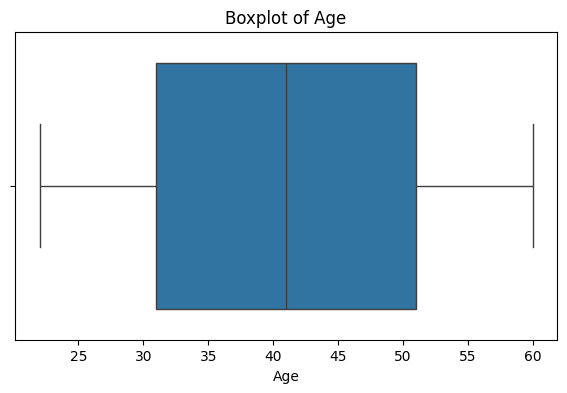

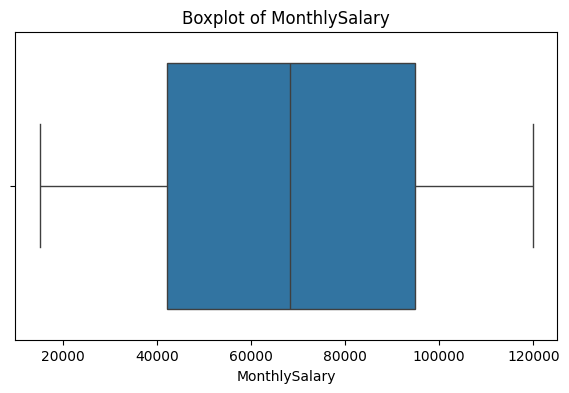

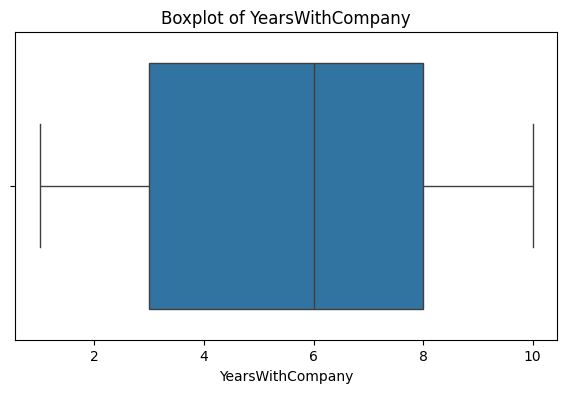

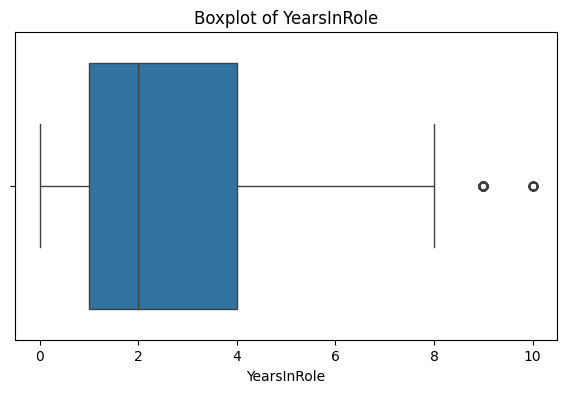

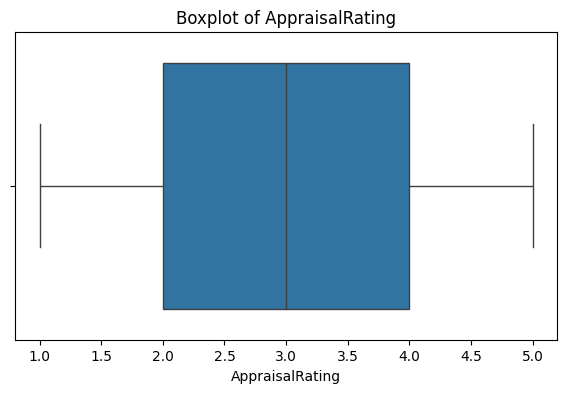

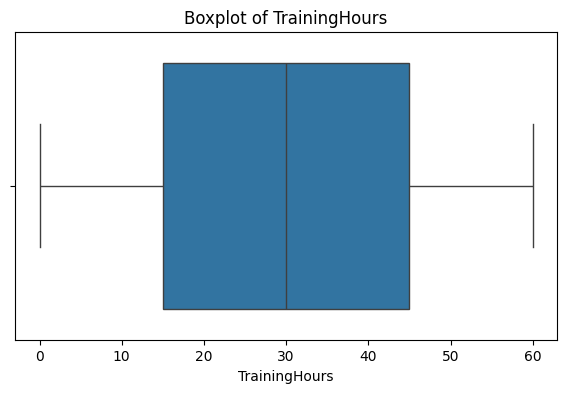

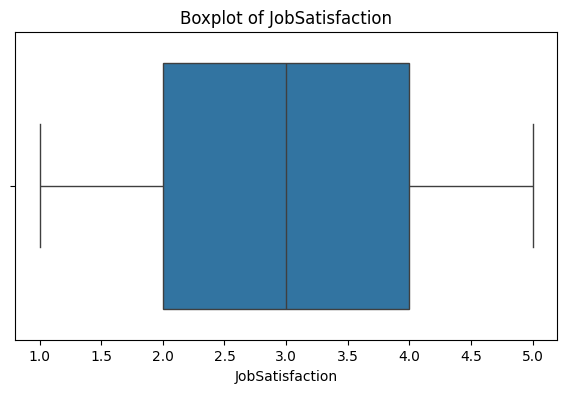

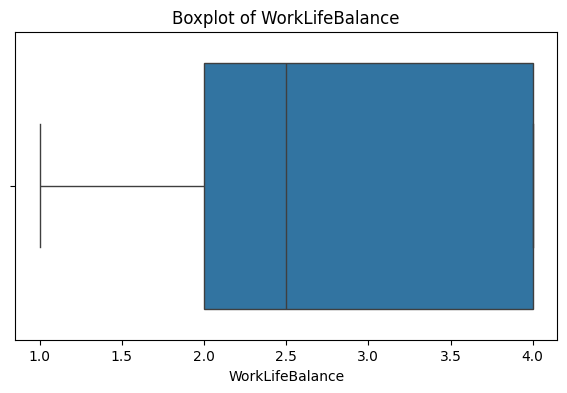

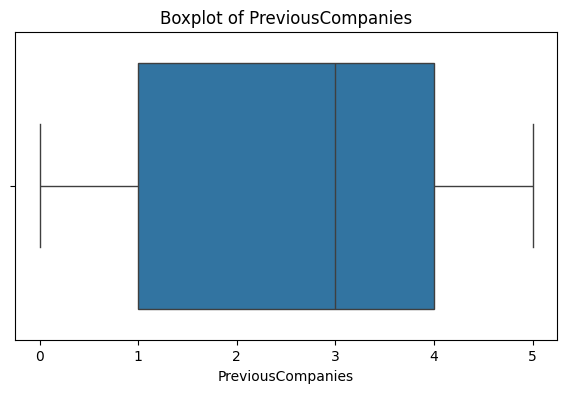

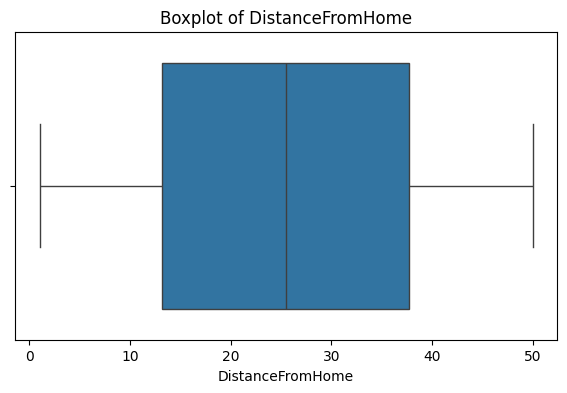

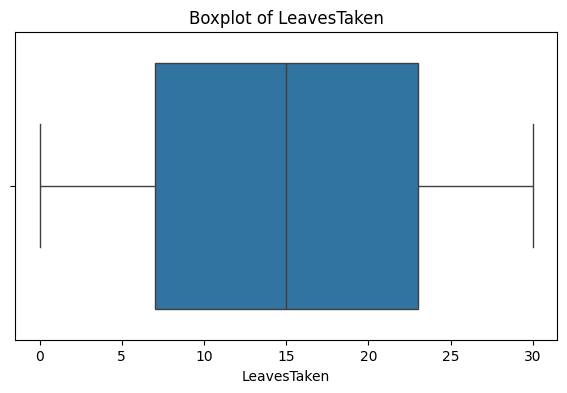

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

In [13]:
outlier_summary = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Age,31.000,51.0,20.000,1.0000,81.0000,0
1,MonthlySalary,42086.000,94889.5,52803.500,-37119.2500,174094.7500,0
2,YearsWithCompany,3.000,8.0,5.000,-4.5000,15.5000,0
3,YearsInRole,1.000,4.0,3.000,-3.5000,8.5000,137
4,AppraisalRating,2.000,4.0,2.000,-1.0000,7.0000,0
5,TrainingHours,15.000,45.0,30.000,-30.0000,90.0000,0
6,JobSatisfaction,2.000,4.0,2.000,-1.0000,7.0000,0
7,WorkLifeBalance,2.000,4.0,2.000,-1.0000,7.0000,0
8,PreviousCompanies,1.000,4.0,3.000,-3.5000,8.5000,0
9,DistanceFromHome,13.175,37.7,24.525,-23.6125,74.4875,0


In [14]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Categorical columns:")
print(list(categorical_columns))

print("\nNumerical columns:")
print(list(numeric_columns))

Categorical columns:
['EmployeeID', 'FullName', 'Gender', 'Department', 'Designation', 'EducationQualification', 'DateOfJoining', 'DoesOvertime', 'MaritalStatus', 'City', 'LeftCompany']

Numerical columns:
['Age', 'MonthlySalary', 'YearsWithCompany', 'YearsInRole', 'AppraisalRating', 'TrainingHours', 'JobSatisfaction', 'WorkLifeBalance', 'PreviousCompanies', 'DistanceFromHome', 'LeavesTaken']


In [15]:
X = df.drop("LeftCompany", axis=1)
y = df["LeftCompany"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5000, 21)
Target shape: (5000,)


In [16]:
X = X.drop(["EmployeeID", "FullName"], axis=1, errors="ignore")

In [17]:
y = y.map({
    "No": 0,
    "Yes": 1
})

y.value_counts()

,count
LeftCompany,
0,3145
1,1855


In [18]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'MonthlySalary', 'YearsWithCompany', 'YearsInRole', 'AppraisalRating', 'TrainingHours', 'JobSatisfaction', 'WorkLifeBalance', 'PreviousCompanies', 'DistanceFromHome', 'LeavesTaken']

Categorical Features:
['Gender', 'Department', 'Designation', 'EducationQualification', 'DateOfJoining', 'DoesOvertime', 'MaritalStatus', 'City']


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [20]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [21]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 19)
Testing data: (1000, 19)


In [24]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (4000, 2388)
Processed testing shape: (1000, 2388)


In [25]:
df.columns.tolist()

['EmployeeID',
 'FullName',
 'Age',
 'Gender',
 'Department',
 'Designation',
 'EducationQualification',
 'MonthlySalary',
 'DateOfJoining',
 'YearsWithCompany',
 'YearsInRole',
 'AppraisalRating',
 'TrainingHours',
 'DoesOvertime',
 'JobSatisfaction',
 'WorkLifeBalance',
 'MaritalStatus',
 'PreviousCompanies',
 'DistanceFromHome',
 'LeavesTaken',
 'City',
 'LeftCompany']

In [26]:
def tenure_group(years):
    if years <= 2:
        return "New"
    elif years <= 5:
        return "Early_Career"
    elif years <= 10:
        return "Mid_Career"
    else:
        return "Experienced"

df["TenureGroup"] = df["YearsWithCompany"].apply(tenure_group)

In [27]:
df["TenureGroup"].value_counts()

,count
TenureGroup,
Mid_Career,2551
Early_Career,1656
New,793


In [28]:
df["OverallSatisfaction"] = (
    df["JobSatisfaction"] + df["WorkLifeBalance"]
) / 2

In [29]:
df[[
    "JobSatisfaction",
    "WorkLifeBalance",
    "OverallSatisfaction"
]].head()

,JobSatisfaction,WorkLifeBalance,OverallSatisfaction
0,4,3,3.5
1,2,2,2.0
2,2,3,2.5
3,4,4,4.0
4,2,2,2.0


In [30]:
df["SalaryPerYearExperience"] = (
    df["MonthlySalary"] /
    (df["YearsWithCompany"] + 1)
)

In [31]:
df["RoleTenureRatio"] = (
    df["YearsInRole"] /
    (df["YearsWithCompany"] + 1)
)